# Unit 02: Computing with Data in Python

# Outline of Unit 02

- **02: Computing with Data in Python**
  - Vector
      - Vectors: assigning, accessing, visualizing
      - Vector addition, subtraction, scaling, linear combination
      - **Inner products, affine function, norm, distance, angle**
  - Matrix
      - **Matrices, special matrices**
      - Matrix transpose, addition, subtraction, scaling
      - Matrix-vector multiplication, Matrix-matrix multiplication

# Outline of Unit 02

- **02: Computing with Data in Python**
  - Vector
      - Vectors: assigning, accessing, visualizing
      - Vector addition, subtraction, scaling, linear combination
      - Inner products, affine function, norm, distance, angle
  - Matrix
      - Matrices, special matrices
      - **Matrix transpose, addition, subtraction, scaling**
      - **Matrix-vector multiplication, Matrix-matrix multiplication**

# Operations on Matrices

## Operations that directly follow from vector operations

### Matrix Addition and Subtraction

$\color{#EF5645}{\text{Definition}}$: Two $n \times m$ matrices A and B can be added or subtracted to give a new $n \times m$ matrix:
$$(A + B)_{ij} = A_{ij} + B_{ij}.$$

### Scalar-Matrix multiplication

$\color{#EF5645}{\text{Definition}}$: A scalar β and an $n \times m$ matrix a can be multiplied to give a new $n \times m$ matrix: 
$$(βA)_{ij} = \beta A_{ij}.$$

### Elementwise-multiplication (Hadamard Product)

$\color{#EF5645}{\text{Definition}}$: Two $n \times m$ matrices $A$ amd $B$ can be multiplied to give a new $n \times m$ matrix: 
$$(A \odot B)_{ij} = A_{ij}B_{ij}.$$

## Frobenius Norm

$\color{#EF5645}{\text{Definition}}$: For a $n \times m$ matrix $A$, we define the _matrix norm_ as:

<center>
$||A|| = \sqrt{\sum_{i=1}^n \sum_{j=1}^m A_{ij}^2}.$</center>

$\color{#EF5645}{\text{Remark}}$: This definition agrees with the definition of norm of vectors when $n=1$ or $m=1$.

$\color{#047C91}{\text{Exercise}}$: Compute the matrix norm of $A = \begin{vmatrix}
1 & 0 & -1\\
0 & 1 & 1 \end{vmatrix}.$

$\color{#003660}{\text{In Python}}$, we use `np.linalg.norm`.

In [27]:
import numpy as np

A = np.array([
    [1, 0, -1],
    [0, 1, 1]
])
print(np.linalg.norm(A))

2.0


$\color{#047C91}{\text{Exercise}}$: Can you write a function that determines the Frobenius norm of a matrix $A$ in terms of the Eulciden norm of its column vectors $a_1, \dots, a_m$?

In [136]:
def frobenius_norm(A):
    n, m = np.shape(A)
    norm = 0
    for j in range(m):
        a = A[:,j]
        norm += np.dot(a,a)
    return np.sqrt(norm)


A = np.array([
    [1, 0, -1],
    [0, 1, 1]
])
print(frobenius_norm(A))

2.0


## Transpose

$\color{#EF5645}{\text{Definition}}$: The _transpose of an $n \times m$ matrix_ $A$ is a $m \times n$ matrix, written $A^T$, and is defined by:
$$ (A^T)_{ij} = A_{ji}, \quad i = 1,...,m \quad j=1,...,n$$

$\color{#047C91}{\text{Example}}$: $\begin{vmatrix}
0.2 & 1.2 & 10 \\
0 & -3 & 0
\end{vmatrix}^T = \begin{vmatrix}
0.2 & 0 \\
1.2 & -3 \\
10 & 0
\end{vmatrix}$


$\color{#6D7D33}{\text{Property}}$: The transpose verifies:
- $(A^T)^T = A$
- $(A + B)^T = A^T + B^T$

_Hint:_ $\color{#003660}{\text{In Python}}$, we use `imshow` to plot an image.

[[ 1  0 -1]
 [ 0  1  0]]
[[ 1  0]
 [ 0  1]
 [-1  0]]


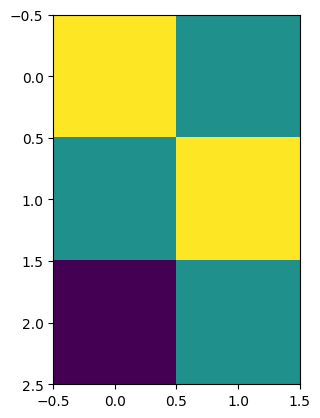

In [6]:
A = np.array([
    [1, 0, -1],
    [0, 1, 0]])

print(A)
print(A.T)
plt.imshow(A)
plt.imshow(A.T)

## Matrix-Vector Multiplication

$\color{#EF5645}{\text{Definition}}$: If $A$ is an $n \times m$ matrix and $x$ is an $m$-vector, then the _matrix-vector_ product $y = Ax$ is the $n$-vector with elements: 
$$y_i = \sum_{j = 1}^m A_{ij}x_j$$

$\color{#047C91}{\text{Example}}$: 

$$\begin{vmatrix}
0 & 2 & -1 \\
-2 & 1 & 1
\end{vmatrix} 
\begin{vmatrix}
2 \\
1 \\
-1
\end{vmatrix} = 
\begin{vmatrix}
3 \\
-4
\end{vmatrix}$$

In [143]:
A = np.array([
    [0, 2, -1],
    [-2, 1, 1]])
x = np.array([2, 1, -1])

y = A @ x
y = A.dot(x)

print(y)

[ 3 -4]


$\color{#047C91}{\text{Exercise}}$: Can you write a function that computes the matrix-vector product only using dot products?

In [144]:
def matrix_vector_dot(A, x):
    n, m = np.shape(A)
#     if m != np.size(x):
#         return False
    y = np.zeros(n)
    for i in range(n):
        a = A[i,:]
        y[i] = np.dot(a, x)
    return y

A = np.array([
    [0, 2, -1],
    [-2, 1, 1]])
x = np.array([2, 1, -1])
y = matrix_vector_dot(A, x)
print(y)

[ 3. -4.]


$\color{#047C91}{\text{Exercise}}$: Can you write a function that computes the matrix-vector product only using linear combinations?

In [145]:
def matrix_vector_linear_comb(A, x):
    n, m = np.shape(A)
    y = np.zeros(n)
    for j in range(m):
        a = A[:,j]
        y += x[j] * a
    return y

A = np.array([
    [0, 2, -1],
    [-2, 1, 1]])
x = np.array([2, 1, -1])
y = matrix_vector_linear_comb(A, x)
print(y)

[ 3. -4.]


$\color{#047C91}{\text{Exercise}}$: If $a$ and $b$ are $n$-vectors, what is the matrix vector product $a^Tb$?

In [3]:
a = np.array([[2, 1, -1, 4, 5, -9]]).T
b = np.array([[-1, 1, 4, 4, -1, 8]]).T
y = a.T @ b
print(y)

[[-66]]


## Matrix-Matrix Multiplication

$\color{#EF5645}{\text{Definition}}$: An $n \times m$ matrix $A$ and a $m \times k$ matrix $B$ be multiplied to give a new $n \times k$ matrix C: 
$$C = AB$$

where the jth column vector of $C$ is given by the matrix vector product $Ab_j$ where $b_j$ is the jth column vector of $B$.

In [6]:
# TODO: Write an example of A B matrix multiplication.
# A = ..
# B = 
# C = 

[[ -2   2   8   8  -2  16]
 [ -1   1   4   4  -1   8]
 [  1  -1  -4  -4   1  -8]
 [ -4   4  16  16  -4  32]
 [ -5   5  20  20  -5  40]
 [  9  -9 -36 -36   9 -72]]


# Recap of Unit 02

- **02: Computing with Data in Python**
  - Vector
      - Vectors: assigning, accessing, visualizing
      - Vector addition, subtraction, scaling, linear combination
      - Inner products, affine function, norm, distance, angle
      - Orthogonality and linear independence
  - Matrix
      - Matrices, special matrices
      - Matrix transpose, addition, subtraction, scaling
      - Matrix-vector multiplication, Matrix-matrix multiplication

# Next week with Louisa!

The course ECE 3 is organized into 4 units.

- Unit 01: Welcome to Python
- Unit 02: Computing with Data in Python
- **Unit 03: Summarizing Data in Python**
- Unit 04: Predicting from Data with Machine Learning in Python